<a href="https://colab.research.google.com/github/Anshitha9286/ASSIGNMENT/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string

In [47]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [49]:
from google.colab import files

uploaded = files.upload()

Saving nlp_dataset.csv to nlp_dataset (1).csv


In [50]:
import os

os.listdir()

['.config', 'nlp_dataset.csv', 'nlp_dataset (1).csv', 'sample_data']

In [51]:
df = pd.read_csv("nlp_dataset.csv")

In [52]:
df.head()

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [53]:
df.columns

Index(['Comment', 'Emotion'], dtype='object')

In [54]:
df.shape

(5937, 2)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5937 entries, 0 to 5936
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  5937 non-null   object
 1   Emotion  5937 non-null   object
dtypes: object(2)
memory usage: 92.9+ KB


In [56]:
df["Comment"].head(10)

,Comment
0,i seriously hate one subject to death but now ...
1,im so full of life i feel appalled
2,i sit here to write i start to dig out my feel...
3,ive been really angry with r and i feel like a...
4,i feel suspicious if there is no one outside l...
5,i feel jealous becasue i wanted that kind of l...
6,when a friend of mine keeps telling me morbid ...
7,i finally fell asleep feeling angry useless an...
8,i feel a bit annoyed and antsy in a good way
9,i feel like i ve regained another vital part o...


In [57]:
df["Emotion"].value_counts()

,count
Emotion,
anger,2000
joy,2000
fear,1937


In [58]:
df.isnull().sum()

,0
Comment,0
Emotion,0


In [59]:
df.duplicated().sum()

np.int64(0)

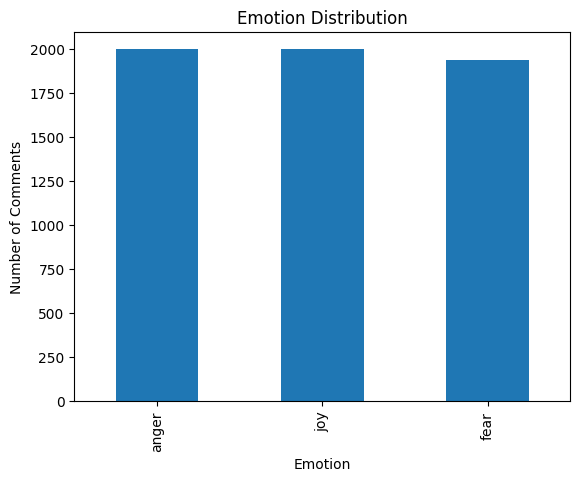

In [60]:
df["Emotion"].value_counts().plot(kind="bar")

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Comments")

plt.show()

In [61]:
stop_words = set(stopwords.words("english"))

In [62]:
list(stop_words)[:20]

['into',
 "you'd",
 "mightn't",
 'had',
 'both',
 'doing',
 'did',
 'too',
 'my',
 'those',
 'didn',
 "we'd",
 'shouldn',
 "that'll",
 'why',
 'himself',
 'now',
 'not',
 "isn't",
 'we']

In [63]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    text = re.sub(r"\d+", "", text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [64]:
sample = "I am VERY happy today!!!"

In [65]:
clean_text(sample)

'happy today'

In [66]:
df["Clean_Comment"] = df["Comment"].apply(clean_text)

In [67]:
df[["Comment", "Clean_Comment", "Emotion"]].head(10)

,Comment,Clean_Comment,Emotion
0,i seriously hate one subject to death but now ...,seriously hate one subject death feel reluctan...,fear
1,im so full of life i feel appalled,im full life feel appalled,anger
2,i sit here to write i start to dig out my feel...,sit write start dig feelings think afraid acce...,fear
3,ive been really angry with r and i feel like a...,ive really angry r feel like idiot trusting fi...,joy
4,i feel suspicious if there is no one outside l...,feel suspicious one outside like rapture happe...,fear
5,i feel jealous becasue i wanted that kind of l...,feel jealous becasue wanted kind love true con...,anger
6,when a friend of mine keeps telling me morbid ...,friend mine keeps telling morbid things happen...,anger
7,i finally fell asleep feeling angry useless an...,finally fell asleep feeling angry useless stil...,anger
8,i feel a bit annoyed and antsy in a good way,feel bit annoyed antsy good way,anger
9,i feel like i ve regained another vital part o...,feel like regained another vital part life living,joy


Preprocessing

The following steps were applied to every comment:
- **Lowercasing**: "Happy" and "happy" become the same token, which shrinks the vocabulary.
- **URL removal**: links carry no emotional meaning.
- **Punctuation and digit removal**: removes symbols that add noise but no emotion.
- **Tokenization**: NLTK splits each comment into individual words.
- **Stopword removal**: very common words ("the", "is", "my") are dropped so the model focuses on informative words.

The dataset had no missing values or duplicates, and the classes are balanced (anger 2000, joy 2000, fear 1937).
The impact on performance is measured in the raw vs. cleaned experiment below.

In [68]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['Emotion_Label'] = label_encoder.fit_transform(df['Emotion'])

df[['Emotion', 'Emotion_Label']].head()

,Emotion,Emotion_Label
0,fear,1
1,anger,0
2,fear,1
3,joy,2
4,fear,1


In [69]:
dict(zip(label_encoder.classes_,
         label_encoder.transform(label_encoder.classes_)))

{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2)}

In [70]:
X = df['Clean_Comment']
y = df['Emotion_Label']

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Feature Extraction: TF-IDF

Machine learning models need numbers, not text. TF-IDF converts each comment into a numeric vector
in which every word or two-word phrase is weighted by:
- **TF (term frequency)**: how often it appears in that comment
- **IDF (inverse document frequency)**: how rare it is across all comments

Distinctive words such as "terrified" get high weights, while common words get low ones.
I used `max_features=5000` to keep the 5,000 most useful terms and `ngram_range=(1,2)` to capture short
phrases like "so angry". The vectorizer is fitted only on the training data to avoid data leakage.

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [73]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {"Naive Bayes": MultinomialNB(), "SVM (LinearSVC)": LinearSVC(random_state=42)}
results, preds = [], {}

for name, clf in models.items():
    clf.fit(X_train_tfidf, y_train)
    preds[name] = clf.predict(X_test_tfidf)
    print(name)
    print(classification_report(y_test, preds[name], target_names=label_encoder.classes_))
    results.append({"Model": name,
                    "Accuracy": accuracy_score(y_test, preds[name]),
                    "Macro F1": f1_score(y_test, preds[name], average="macro")})

pd.DataFrame(results)

Naive Bayes
              precision    recall  f1-score   support

       anger       0.91      0.92      0.91       400
        fear       0.92      0.92      0.92       388
         joy       0.92      0.91      0.92       400

    accuracy                           0.92      1188
   macro avg       0.92      0.92      0.92      1188
weighted avg       0.92      0.92      0.92      1188

SVM (LinearSVC)
              precision    recall  f1-score   support

       anger       0.95      0.93      0.94       400
        fear       0.95      0.95      0.95       388
         joy       0.95      0.96      0.96       400

    accuracy                           0.95      1188
   macro avg       0.95      0.95      0.95      1188
weighted avg       0.95      0.95      0.95      1188



,Model,Accuracy,Macro F1
0,Naive Bayes,0.915825,0.915857
1,SVM (LinearSVC),0.947811,0.947786


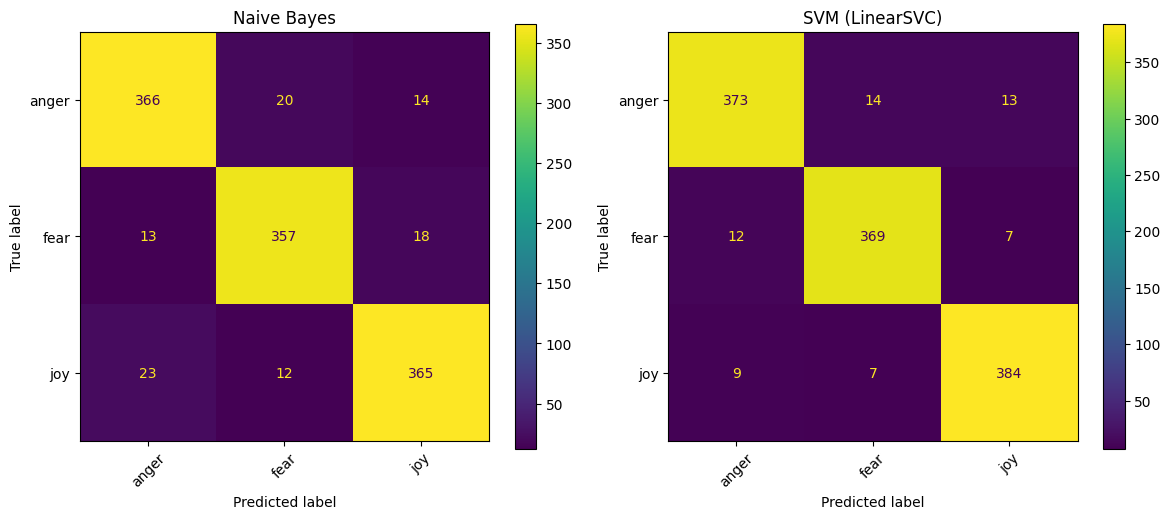

In [74]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pred) in zip(axes, preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=label_encoder.classes_,
        ax=ax, xticks_rotation=45)
    ax.set_title(name)
plt.tight_layout()
plt.show()

Impact of Preprocessing

The same SVM scored **91.6%** accuracy on raw text and **94.8%** on cleaned text, an improvement of about
3 percentage points. Since the comments were already mostly lowercase and unpunctuated, the gain likely comes
mainly from removing stopwords, which lets the model focus on emotion-bearing words.

In [75]:
raw_train, raw_test, yr_train, yr_test = train_test_split(
    df['Comment'], y, test_size=0.2, random_state=42, stratify=y)

raw_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
svm_raw = LinearSVC(random_state=42).fit(raw_tfidf.fit_transform(raw_train), yr_train)

print("SVM on raw text:    ", accuracy_score(yr_test, svm_raw.predict(raw_tfidf.transform(raw_test))))
print("SVM on cleaned text:", accuracy_score(y_test, preds["SVM (LinearSVC)"]))

SVM on raw text:     0.9158249158249159
SVM on cleaned text: 0.9478114478114478


Model Comparison

| Model | Accuracy | Macro F1 |
|---|---|---|
| Naive Bayes | 0.916 | 0.916 |
| SVM (LinearSVC) | 0.948 | 0.948 |

SVM performed best and is the chosen model. It handles high-dimensional, sparse TF-IDF features well and
finds a strong separating boundary between anger, fear and joy. Naive Bayes is fast and simple, but it assumes
words are independent of each other, which limits it when emotion depends on phrasing.
Accuracy and macro F1 are used because the classes are balanced and macro F1 treats all three emotions equally.
The confusion matrices show both models classify all three emotions well, with SVM making fewer errors.

In [76]:
best_model = models["SVM (LinearSVC)"]

def predict_emotion(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    return label_encoder.inverse_transform(best_model.predict(vec))[0]

print(predict_emotion("I am very scared about what will happen tomorrow"))
print(predict_emotion("I am extremely happy today"))
print(predict_emotion("I am so angry with him"))

fear
joy
anger
